In [1]:
import sys,os
sys.path.append(r'X:/Strategies/LeadLagXGB/')
sys.path.append(r'Z:/EnergyTrading/Python/')
sys.path.append(r'Z:/EnergyTrading/Python/Strategies/LeadLagXGB/')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta
from SynthSpread.spreadviewer_class import SpreadSingle, SpreadViewerData, norm_coeff
#from Database.TPData import TPData, TPDataDa, TPDataAssembly
from Database.TPData import TPData, TPDataDa, TPDataAssembly
from Database.DB_reader import Database
from datetime import date, timedelta

In [3]:
#importing custom library
!pip install git+https://github.com/Vrboska/mofr@master

  Cloning https://github.com/Vrboska/mofr (to revision master) to c:\users\andrej\appdata\local\temp\pip-req-build-tdihm1bt
  Resolved https://github.com/Vrboska/mofr to commit 3509aedad3ad1469ec00fecd358b78860d8afb6f
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/Vrboska/mofr 'C:\Users\andrej\AppData\Local\Temp\pip-req-build-tdihm1bt'
  Running command git checkout -b master --track origin/master
  branch 'master' set up to track 'origin/master'.
  Switched to a new branch 'master'


In [4]:
import mofr

# Data Loading

In [5]:
# 1. Read data from source DB
conn = Database('timescaledb')

query=f"""select * from user_andrej_zubal.deq1_predictors""" # where rownum <= 100"""
df=conn.execute(query)


print(f"✅ Loaded {len(df)} rows from source database.")

Connected to the database timescaledb
Disconnected from the database timescaledb
✅ Loaded 1309271 rows from source database.


In [6]:
df=df[df['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [7]:
labels=pd.read_csv('labels_deq1.csv')

In [8]:
df=df.merge(labels, on='tradeid', how='inner').sort_values('datetime')

In [9]:
df.head()

,datetime,tradeid,contract,ll_dem1_deq1_fair_price,ll_dem2_deq1_fair_price,ll_ttfm1_deq1_fair_price,ll_aux_ens_deq1_fair_price,ll_aux_ens_deq1_fair_ret,obook_a_price_deq1,obook_a_price_sparsity_deq1,...,vpin_50_deq1,Unnamed: 0,timestamp,dti_300s,dti_300s.1,dti_300s.2,b_price,a_price,label_bid,label_ask
133370,2025-03-17 09:00:56.014312,Eurex T7/DEBQ042025-20250317/402/1,deq1,None,None,None,74.56480259318384,0.0,75.4,0.18,...,None,0,2025-03-17 09:00:56.014312273,0.000000,0.000000,0.000000,75.26,75.40,1,1
133371,2025-03-17 09:00:56.014360,Eurex T7/DEBQ042025-20250317/403/1,deq1,None,None,None,74.98610339082006,0.0,75.4,0.18,...,None,1,2025-03-17 09:00:56.014360655,0.000000,0.000000,0.000000,75.26,75.40,1,1
133372,2025-03-17 09:00:56.027458,Eurex T7/DEBQ042025-20250317/404/1,deq1,None,None,None,75.15422745518212,0.0,75.4,0.27,...,None,2,2025-03-17 09:00:56.027458802,0.006667,0.006667,0.006667,75.26,75.40,1,1
133411,2025-03-17 09:02:49.296080,Eurex T7/DEBQ042025-20250317/441/1,deq1,None,None,None,75.19695640945697,0.0,75.39,0.16,...,None,3,2025-03-17 09:02:49.296080919,-0.010000,-0.010000,-0.010000,75.25,75.39,0,1
133433,2025-03-17 09:05:14.250022,Eurex T7/DEBQ042025-20250317/492/1,deq1,None,None,None,75.22180533024449,0.0,75.27,0.16,...,None,4,2025-03-17 09:05:14.250022894,-0.013333,-0.013333,-0.013333,75.04,75.27,1,0


In [10]:
# 1. Add a date column for grouping
df['date'] = df['datetime'].dt.date

# 2. Sort for proper ffill order
df = df.sort_values(['date', 'datetime'])

# 3. Perform forward fill within each date
df = df.groupby('date').apply(lambda g: g.ffill()).reset_index(drop=True)

# 4. (Optional) Drop the helper column if you don't need it anymore
df.drop(columns='date', inplace=True)

C:\Users\andrej\AppData\Local\Temp\ipykernel_27688\1671415354.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('date').apply(lambda g: g.ffill()).reset_index(drop=True)


In [11]:
df.shape

(190786, 41)

In [12]:
del df['Unnamed: 0']
df['mid_price']=(df['b_price']+df['a_price'])/2.0
df['ba_spread']=-1*(df['b_price']-df['a_price'])

In [13]:
df.head()

,datetime,tradeid,contract,ll_dem1_deq1_fair_price,ll_dem2_deq1_fair_price,ll_ttfm1_deq1_fair_price,ll_aux_ens_deq1_fair_price,ll_aux_ens_deq1_fair_ret,obook_a_price_deq1,obook_a_price_sparsity_deq1,...,timestamp,dti_300s,dti_300s.1,dti_300s.2,b_price,a_price,label_bid,label_ask,mid_price,ba_spread
0,2025-03-17 09:00:56.014312,Eurex T7/DEBQ042025-20250317/402/1,deq1,None,None,None,74.56480259318384,0.0,75.4,0.18,...,2025-03-17 09:00:56.014312273,0.000000,0.000000,0.000000,75.26,75.40,1,1,75.330,0.14
1,2025-03-17 09:00:56.014360,Eurex T7/DEBQ042025-20250317/403/1,deq1,None,None,None,74.98610339082006,0.0,75.4,0.18,...,2025-03-17 09:00:56.014360655,0.000000,0.000000,0.000000,75.26,75.40,1,1,75.330,0.14
2,2025-03-17 09:00:56.027458,Eurex T7/DEBQ042025-20250317/404/1,deq1,None,None,None,75.15422745518212,0.0,75.4,0.27,...,2025-03-17 09:00:56.027458802,0.006667,0.006667,0.006667,75.26,75.40,1,1,75.330,0.14
3,2025-03-17 09:02:49.296080,Eurex T7/DEBQ042025-20250317/441/1,deq1,None,None,None,75.19695640945697,0.0,75.39,0.16,...,2025-03-17 09:02:49.296080919,-0.010000,-0.010000,-0.010000,75.25,75.39,0,1,75.320,0.14
4,2025-03-17 09:05:14.250022,Eurex T7/DEBQ042025-20250317/492/1,deq1,None,None,None,75.22180533024449,0.0,75.27,0.16,...,2025-03-17 09:05:14.250022894,-0.013333,-0.013333,-0.013333,75.04,75.27,1,0,75.155,0.23


In [14]:
df.columns

Index(['datetime', 'tradeid', 'contract', 'll_dem1_deq1_fair_price',
       'll_dem2_deq1_fair_price', 'll_ttfm1_deq1_fair_price',
       'll_aux_ens_deq1_fair_price', 'll_aux_ens_deq1_fair_ret',
       'obook_a_price_deq1', 'obook_a_price_sparsity_deq1', 'obook_a_vol_deq1',
       'obook_b_price_deq1', 'obook_b_price_sparsity_deq1', 'obook_b_vol_deq1',
       'obook_ba_spread_deq1', 'obook_ba_volrat_00_deq1',
       'obook_ba_volrat_30_deq1', 'obook_ba_volrat_50_deq1',
       'obook_ba_volrat_90_deq1', 'obook_mid_pricew_00_deq1',
       'obook_mid_pricew_30_deq1', 'obook_mid_pricew_50_deq1',
       'obook_mid_pricew_90_deq1', 'obook_mid_pricew_d_00_deq1',
       'obook_mid_pricew_d_30_deq1', 'obook_mid_pricew_d_50_deq1',
       'obook_mid_pricew_d_90_deq1', 'obook_mid_price_deq1', 'vpin_100_deq1',
       'vpin_10_deq1', 'vpin_20_deq1', 'vpin_50_deq1', 'timestamp', 'dti_300s',
       'dti_300s.1', 'dti_300s.2', 'b_price', 'a_price', 'label_bid',
       'label_ask', 'mid_price', 'ba_spr

In [15]:
df=df.dropna(subset=['ll_aux_ens_deq1_fair_price'])

# Predictor exploration

In [16]:
# Assume df is already loaded and has a datetime column
# Filter out only predictors (not identifiers or price/volume)
exclude = {'datetime', 'tradeid', 'contract', 'trd_price', 'volume'}
predictor_cols = [col for col in df.columns if col not in exclude]

# Calculate null percentage per predictor per month
df['month'] = df['datetime'].dt.to_period('M')
null_pct = df.groupby('month')[predictor_cols].apply(lambda x: x.isnull().mean() * 100)
# Show the full DataFrame without truncation
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(null_pct)

,ll_dem1_deq1_fair_price,ll_dem2_deq1_fair_price,ll_ttfm1_deq1_fair_price,ll_aux_ens_deq1_fair_price,ll_aux_ens_deq1_fair_ret,obook_a_price_deq1,obook_a_price_sparsity_deq1,obook_a_vol_deq1,obook_b_price_deq1,obook_b_price_sparsity_deq1,obook_b_vol_deq1,obook_ba_spread_deq1,obook_ba_volrat_00_deq1,obook_ba_volrat_30_deq1,obook_ba_volrat_50_deq1,obook_ba_volrat_90_deq1,obook_mid_pricew_00_deq1,obook_mid_pricew_30_deq1,obook_mid_pricew_50_deq1,obook_mid_pricew_90_deq1,obook_mid_pricew_d_00_deq1,obook_mid_pricew_d_30_deq1,obook_mid_pricew_d_50_deq1,obook_mid_pricew_d_90_deq1,obook_mid_price_deq1,vpin_100_deq1,vpin_10_deq1,vpin_20_deq1,vpin_50_deq1,timestamp,dti_300s,dti_300s.1,dti_300s.2,b_price,a_price,label_bid,label_ask,mid_price,ba_spread
month,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-03,0.600111,100.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.174867,0.174867,0.174867,0.174867,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-04,0.428814,100.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001054,0.001054,0.112735,0.112735,0.112735,0.112735,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-05,0.475174,100.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.123036,0.123036,0.123036,0.123036,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


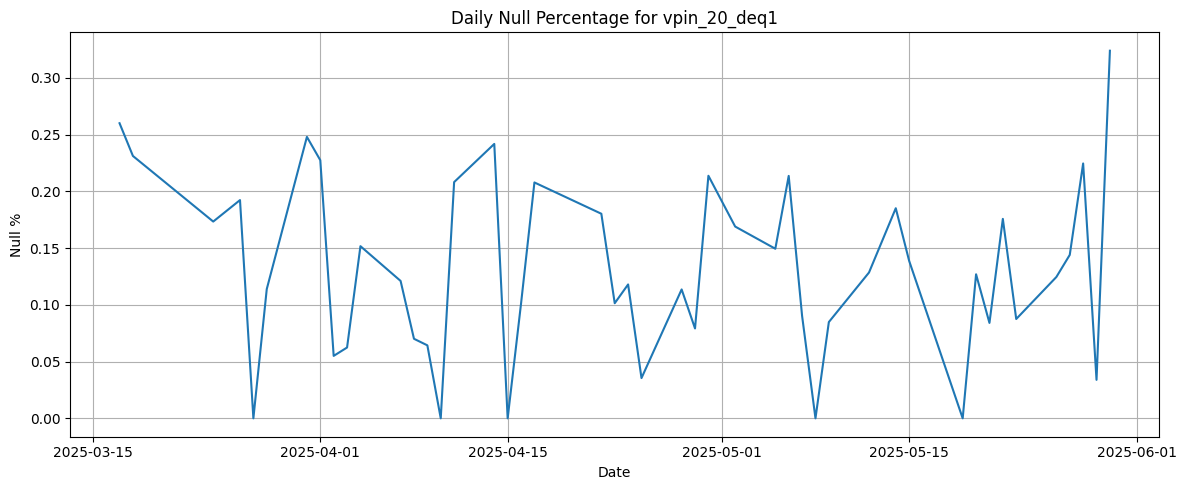

In [17]:

# Replace this with your actual predictor name
predictor = "vpin_20_deq1"

# Ensure datetime is parsed correctly
df['datetime'] = pd.to_datetime(df['datetime'])

# Extract date
df['date'] = df['datetime'].dt.date

# Calculate daily null percentage for the predictor
daily_null_pct = df.groupby('date')[predictor].apply(lambda x: x.isnull().mean() * 100)

# Plot
plt.figure(figsize=(12, 5))
daily_null_pct.plot(title=f'Daily Null Percentage for {predictor}')
plt.ylabel('Null %')
plt.xlabel('Date')
plt.grid(True)
plt.tight_layout()
plt.show()


In [18]:
from decimal import Decimal

# Define a large number to replace infinities
large_number = 1e10

# Replace both positive and negative infinity
df.replace([np.inf, -np.inf], large_number, inplace=True)

df = df.applymap(lambda x: float(x) if isinstance(x, Decimal) else x)

C:\Users\andrej\AppData\Local\Temp\ipykernel_27688\3392917933.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: float(x) if isinstance(x, Decimal) else x)


# Longs

In [19]:
df['ll_dem1_deq1_fair_price_diff_mid']=df['ll_dem1_deq1_fair_price'].astype(float)-df['mid_price'].astype(float)
df['ll_aux_ens_deq1_fair_price_diff_mid']=df['ll_aux_ens_deq1_fair_price'].astype(float)-df['mid_price'].astype(float)

In [20]:
#df_long=df[(df['contract']=='dem2')&(df['trd_price'].apply(float)-df['ask_price']>0.0)]
#df_long=df[(df['ll_aux_ens_deq1_fair_price']-df['a_price']>0.0) & (df['contract']=='dem1')]
df_long=df[(df['contract']=='dem1')]

In [21]:
target_col='label_bid'
target_col2='label_bid'

feature_cols=['ll_dem1_deq1_fair_price',
       'll_aux_ens_deq1_fair_price', 
       'll_aux_ens_deq1_fair_ret',
       'obook_a_price_deq1', 'obook_a_price_sparsity_deq1', 'obook_a_vol_deq1',
       'obook_b_price_deq1', 'obook_b_price_sparsity_deq1', 'obook_b_vol_deq1',
       'obook_ba_spread_deq1', 'obook_ba_volrat_00_deq1',
       'obook_ba_volrat_30_deq1', 'obook_ba_volrat_50_deq1',
       'obook_ba_volrat_90_deq1', 'obook_mid_pricew_00_deq1',
       'obook_mid_pricew_30_deq1', 'obook_mid_pricew_50_deq1',
       'obook_mid_pricew_90_deq1', 'obook_mid_pricew_d_00_deq1',
       'obook_mid_pricew_d_30_deq1', 'obook_mid_pricew_d_50_deq1',
       'obook_mid_pricew_d_90_deq1', 'obook_mid_price_deq1', 'vpin_100_deq1',
       'vpin_10_deq1', 'vpin_20_deq1', 'vpin_50_deq1', 'dti_300s']

In [22]:
df_long=df_long.dropna(subset=feature_cols+[target_col])

In [23]:
df_long[target_col].value_counts()

label_bid
0    52860
1    48622
Name: count, dtype: int64

In [24]:
df_long[target_col].value_counts(normalize=True)

label_bid
0    0.520881
1    0.479119
Name: proportion, dtype: float64

## Univariate predictor analysis

In [25]:
result = []
for feat in feature_cols:
    try:
        print(feat)
        gini = mofr.metrics.gini(df_long[target_col].apply(float), df_long[feat].apply(float))
        result.append((feat, gini))
    except:
        print('problem')

pd.DataFrame(result, columns=["feature", "gini"]).sort_values(by="gini", key=lambda x: x.abs(), ascending=False)

ll_dem1_deq1_fair_price
ll_aux_ens_deq1_fair_price
ll_aux_ens_deq1_fair_ret
obook_a_price_deq1
obook_a_price_sparsity_deq1
obook_a_vol_deq1
obook_b_price_deq1
obook_b_price_sparsity_deq1
obook_b_vol_deq1
obook_ba_spread_deq1
obook_ba_volrat_00_deq1
obook_ba_volrat_30_deq1
obook_ba_volrat_50_deq1
obook_ba_volrat_90_deq1
obook_mid_pricew_00_deq1
obook_mid_pricew_30_deq1
obook_mid_pricew_50_deq1
obook_mid_pricew_90_deq1
obook_mid_pricew_d_00_deq1
obook_mid_pricew_d_30_deq1
obook_mid_pricew_d_50_deq1
obook_mid_pricew_d_90_deq1
obook_mid_price_deq1
vpin_100_deq1
vpin_10_deq1
vpin_20_deq1
vpin_50_deq1
dti_300s


,feature,gini
9,obook_ba_spread_deq1,-0.273680
2,ll_aux_ens_deq1_fair_ret,0.181600
4,obook_a_price_sparsity_deq1,0.145086
18,obook_mid_pricew_d_00_deq1,-0.129989
10,obook_ba_volrat_00_deq1,0.122907
5,obook_a_vol_deq1,-0.121770
11,obook_ba_volrat_30_deq1,0.116389
27,dti_300s,0.076814
8,obook_b_vol_deq1,0.066341
12,obook_ba_volrat_50_deq1,0.061764


In [26]:
# Calculate monthly gini for ll_aux_ens_dem2_fair_price_diff_mid
df_long['month'] = df_long['datetime'].dt.month
monthly_gini = []

for month in sorted(df_long['month'].unique()):
    month_mask = df_long['month'] == month
    month_data = df_long[month_mask]
    
    gini = mofr.metrics.gini(
        month_data[target_col].apply(float), 
        month_data['ll_aux_ens_deq1_fair_price_diff_mid'].apply(float)
    )
    
    monthly_gini.append({
        'month': month,
        'gini': gini
    })

gini_df = pd.DataFrame(monthly_gini)
print('Monthly Gini Coefficients for ll_aux_ens_deq1_fair_price_diff_mid:')
display(gini_df)

# Calculate overall gini for reference
overall_gini = mofr.metrics.gini(
    df_long[target_col].apply(float), 
    df_long['ll_aux_ens_deq1_fair_price_diff_mid'].apply(float)
)
print(f'\nOverall Gini: {overall_gini:.4f}')

Monthly Gini Coefficients for ll_aux_ens_deq1_fair_price_diff_mid:


,month,gini
0,3,0.105630
1,4,0.110186
2,5,0.134527



Overall Gini: 0.1173


## XGB model

In [27]:
# --- Month-based XGBoost model training and evaluation for LONGS ---
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import calendar

# Prepare date column
if 'date' not in df_long.columns:
    df_long['date'] = df_long['datetime'].dt.date
if 'month' not in df_long.columns:
    df_long['month'] = pd.to_datetime(df_long['date']).dt.to_period('M')

unique_months = sorted(df_long['month'].unique())

all_predictions = []
all_actual_values = []
all_probabilities = []
all_dates = []

for i, month in enumerate(unique_months):
    # Use all data before the current month for training
    train_months = unique_months[:i]
    if len(train_months) == 0:
        continue
    train_mask = df_long['month'].isin(train_months)
    test_mask = df_long['month'] == month
    X_train = df_long.loc[train_mask, feature_cols]
    y_train = df_long.loc[train_mask, target_col]
    X_test = df_long.loc[test_mask, feature_cols]
    y_test = df_long.loc[test_mask, target_col]
    test_dates = df_long.loc[test_mask, 'date']
    if len(X_test) == 0 or len(X_train) == 0:
        continue
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum() if y_train.sum() > 0 else 1
    model = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_pred_proba > 0.5).astype(int)
    all_predictions.extend(y_pred)
    all_actual_values.extend(y_test)
    all_probabilities.extend(y_pred_proba)
    all_dates.extend(list(test_dates))

results_df_long = pd.DataFrame({
    'date': all_dates,
    'actual': all_actual_values,
    'predicted': all_predictions,
    'probability': all_probabilities
})

results_df_long['month'] = pd.to_datetime(results_df_long['date']).dt.month
monthly_metrics = []
for month in sorted(results_df_long['month'].unique()):
    month_mask = results_df_long['month'] == month
    month_data = results_df_long[month_mask]
    lift = mofr.metrics.lift(month_data['actual'], month_data['probability'])
    gini = mofr.metrics.gini(month_data['actual'].apply(int), month_data['probability'])
    sorted_data = month_data.sort_values('probability', ascending=False)
    top_100 = sorted_data.head(100)
    precision_top_100 = top_100['actual'].mean() if len(top_100) == 100 else None
    monthly_metrics.append({
        'month': month,
        'lift': lift,
        'gini': gini,
        'precision_top_100': precision_top_100
    })
metrics_df_long = pd.DataFrame(monthly_metrics)
print('Monthly Performance Metrics (Longs):')
display(metrics_df_long)

print('\nOverall Performance Metrics (Longs):')
if len(results_df_long) == 0:
    print('No predictions available for overall metrics.')
else:
    print('Lift:', mofr.metrics.lift(results_df_long['actual'], results_df_long['probability']))
    print('Gini:', mofr.metrics.gini(results_df_long['actual'].apply(int), results_df_long['probability']))
    sorted_overall = results_df_long.sort_values('probability', ascending=False)
    top_100_overall = sorted_overall.head(100)
    precision_top_100_overall = top_100_overall['actual'].mean() if len(top_100_overall) == 50 else None
    print(f'Precision (top 50): {precision_top_100_overall:.4f}' if precision_top_100_overall is not None else "N/A")

Monthly Performance Metrics (Longs):


,month,lift,gini,precision_top_100
0,4,1.342301,0.217716,0.82
1,5,1.550654,0.300390,0.84



Overall Performance Metrics (Longs):
Lift: 1.388405264303028
Gini: 0.26049670946612125
N/A


In [28]:
results_df_long[results_df_long['month']==5].groupby('probability').agg(count=('probability', 'size'), mean_target=('actual', 'mean')).sort_index(ascending=False).head(20)


,count,mean_target
probability,,
0.966045,1,1.0
0.953819,1,0.0
0.952545,1,0.0
0.950238,1,1.0
0.944174,2,1.0
0.940839,2,1.0
0.938495,1,1.0
0.938048,1,1.0
0.933429,2,1.0


# Shorts

In [29]:
df['ll_dem1_deq1_fair_price_diff_mid']=df['ll_dem1_deq1_fair_price']-df['mid_price']
df['ll_aux_ens_deq1_fair_price_diff_mid']=df['ll_aux_ens_deq1_fair_price']-df['mid_price']

In [30]:
#df_short=df[(df['contract']=='dem2')&(df['bid_price']-df['trd_price'].apply(float)>0.0)]
#df_short=df[(-df['ll_aux_ens_dem2_fair_price']+df['bid_price']>0.03) & (df['contract']=='dem1')]
df_short=df[(df['contract']=='dem1')]

In [31]:
target_col='label_ask'
feature_cols=['ll_dem1_deq1_fair_price',
'll_aux_ens_deq1_fair_price', 
'll_aux_ens_deq1_fair_ret',
'obook_a_price_deq1', 'obook_a_price_sparsity_deq1', 'obook_a_vol_deq1',
'obook_b_price_deq1', 'obook_b_price_sparsity_deq1', 'obook_b_vol_deq1',
'obook_ba_spread_deq1', 'obook_ba_volrat_00_deq1',
'obook_ba_volrat_30_deq1', 'obook_ba_volrat_50_deq1',
'obook_ba_volrat_90_deq1', 'obook_mid_pricew_00_deq1',
'obook_mid_pricew_30_deq1', 'obook_mid_pricew_50_deq1',
'obook_mid_pricew_90_deq1', 'obook_mid_pricew_d_00_deq1',
'obook_mid_pricew_d_30_deq1', 'obook_mid_pricew_d_50_deq1',
'obook_mid_pricew_d_90_deq1', 'obook_mid_price_deq1', 'vpin_100_deq1',
'vpin_10_deq1', 'vpin_20_deq1', 'vpin_50_deq1', 'dti_300s']

In [32]:
df_short=df_short.dropna(subset=feature_cols+[target_col])

In [33]:
df_short[target_col].value_counts()

label_ask
0    52658
1    48824
Name: count, dtype: int64

In [34]:
df_short[target_col].value_counts(normalize=True)

label_ask
0    0.51889
1    0.48111
Name: proportion, dtype: float64

## Univariate predictor analysis

In [35]:
result = []
for feat in feature_cols:
    try:
        print(feat)
        gini = mofr.metrics.gini(df_short[target_col].apply(float), df_short[feat].apply(float))
        result.append((feat, gini))
    except:
        print('problem')

pd.DataFrame(result, columns=["feature", "gini"]).sort_values(by="gini", key=lambda x: x.abs(), ascending=False)

ll_dem1_deq1_fair_price
ll_aux_ens_deq1_fair_price
ll_aux_ens_deq1_fair_ret
obook_a_price_deq1
obook_a_price_sparsity_deq1
obook_a_vol_deq1
obook_b_price_deq1
obook_b_price_sparsity_deq1
obook_b_vol_deq1
obook_ba_spread_deq1
obook_ba_volrat_00_deq1
obook_ba_volrat_30_deq1
obook_ba_volrat_50_deq1
obook_ba_volrat_90_deq1
obook_mid_pricew_00_deq1
obook_mid_pricew_30_deq1
obook_mid_pricew_50_deq1
obook_mid_pricew_90_deq1
obook_mid_pricew_d_00_deq1
obook_mid_pricew_d_30_deq1
obook_mid_pricew_d_50_deq1
obook_mid_pricew_d_90_deq1
obook_mid_price_deq1
vpin_100_deq1
vpin_10_deq1
vpin_20_deq1
vpin_50_deq1
dti_300s


,feature,gini
9,obook_ba_spread_deq1,-0.285218
2,ll_aux_ens_deq1_fair_ret,-0.215789
27,dti_300s,-0.151695
10,obook_ba_volrat_00_deq1,-0.140870
18,obook_mid_pricew_d_00_deq1,0.137844
8,obook_b_vol_deq1,-0.132831
7,obook_b_price_sparsity_deq1,0.125914
11,obook_ba_volrat_30_deq1,-0.119434
23,vpin_100_deq1,-0.082033
5,obook_a_vol_deq1,0.080347


## Month-based Logistic Regression Model (Shorts)
This cell implements the month-based model training and evaluation for the shorts strategy. The model is trained on all available data up to the end of each month and used to predict for the following month. Metrics include precision@100, lift, gini, and accuracy, both monthly and overall.

In [36]:
# --- Month-based XGBoost model training and evaluation for SHORTS ---
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import calendar

if 'date' not in df_short.columns:
    df_short['date'] = df_short['datetime'].dt.date
if 'month' not in df_short.columns:
    df_short['month'] = pd.to_datetime(df_short['date']).dt.to_period('M')

unique_months = sorted(df_short['month'].unique())

all_predictions = []
all_actual_values = []
all_probabilities = []
all_dates = []

for i, month in enumerate(unique_months):
    train_months = unique_months[:i]
    if len(train_months) == 0:
        continue
    train_mask = df_short['month'].isin(train_months)
    test_mask = df_short['month'] == month
    X_train = df_short.loc[train_mask, feature_cols]
    y_train = df_short.loc[train_mask, target_col]
    X_test = df_short.loc[test_mask, feature_cols]
    y_test = df_short.loc[test_mask, target_col]
    test_dates = df_short.loc[test_mask, 'date']
    if len(X_test) == 0 or len(X_train) == 0:
        continue
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum() if y_train.sum() > 0 else 1
    model = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_pred_proba > 0.5).astype(int)
    all_predictions.extend(y_pred)
    all_actual_values.extend(y_test)
    all_probabilities.extend(y_pred_proba)
    all_dates.extend(list(test_dates))

results_df_short = pd.DataFrame({
    'date': all_dates,
    'actual': all_actual_values,
    'predicted': all_predictions,
    'probability': all_probabilities
})

results_df_short['month'] = pd.to_datetime(results_df_short['date']).dt.month
monthly_metrics = []
for month in sorted(results_df_short['month'].unique()):
    month_mask = results_df_short['month'] == month
    month_data = results_df_short[month_mask]
    lift = mofr.metrics.lift(month_data['actual'], month_data['probability'])
    gini = mofr.metrics.gini(month_data['actual'].apply(int), month_data['probability'])
    sorted_data = month_data.sort_values('probability', ascending=False)
    top_100 = sorted_data.head(100)
    precision_top_100 = top_100['actual'].mean() if len(top_100) == 100 else None
    monthly_metrics.append({
        'month': month,
        'lift': lift,
        'gini': gini,
        'precision_top_100': precision_top_100
    })
metrics_df_short = pd.DataFrame(monthly_metrics)
print('Monthly Performance Metrics (Shorts):')
display(metrics_df_short)

print('\nOverall Performance Metrics (Shorts):')
if len(results_df_short) == 0:
    print('No predictions available for overall metrics (Shorts).')
else:
    print('Lift:', mofr.metrics.lift(results_df_short['actual'], results_df_short['probability']))
    print('Gini:', mofr.metrics.gini(results_df_short['actual'].apply(int), results_df_short['probability']))
    sorted_overall = results_df_short.sort_values('probability', ascending=False)
    top_100_overall = sorted_overall.head(100)
    precision_top_100_overall = top_100_overall['actual'].mean() if len(top_100_overall) == 50 else None
    print(f'Precision (top 50): {precision_top_100_overall:.4f}' if precision_top_100_overall is not None else "N/A")

Monthly Performance Metrics (Shorts):


,month,lift,gini,precision_top_100
0,4,1.286297,0.154686,0.71
1,5,1.493870,0.320959,0.82



Overall Performance Metrics (Shorts):
Lift: 1.3933370757531378
Gini: 0.22554750220335817
N/A


In [37]:
# df_export=pd.concat([df_short[df_short['date'].apply(str)>='2025-02-01'][['datetime', 'tradeid', 'contract']].reset_index(drop=True), results_df_short], axis=1)
# df_export['datetime'] = pd.to_datetime(df_export['datetime'])
# df_export['tradeid'] = df_export['tradeid'].astype(str)  # or .astype(int) if DB expects int
# df_export['contract'] = df_export['contract'].astype(str)
# df_export['actual'] = df_export['actual'].astype(float)
# df_export['predicted'] = df_export['predicted'].astype(int)
# df_export['probability'] = df_export['probability'].astype(float)
# df_export['month'] = df_export['month'].astype(int)

# print(df_export.dtypes)

# conn = Database('timescaledb')
# conn._connect()


# df_export.to_sql('user_andrej_zubal.dem2_xgb_short_score', conn.engine, index=False, if_exists='append', method='multi', chunksize=1000)

In [38]:
results_df_short[results_df_short['month']==4].groupby('probability').agg(count=('probability', 'size'), mean_target=('actual', 'mean')).sort_index(ascending=False).head(20)


,count,mean_target
probability,,
0.968661,7,1.0
0.968341,7,1.0
0.965346,3,1.0
0.962108,1,1.0
0.961631,2,1.0
0.959901,2,0.0
0.958945,1,1.0
0.956621,7,1.0
0.954230,1,1.0


Training long model...


[13:38:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[13:38:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[13:38:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[13:38:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-au

[13:38:09] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[13:38:09] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[13:38:09] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[13:38:09] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-au

Overall accuracy (long): 0.6196

Training short model...


[13:38:09] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[13:38:10] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[13:38:10] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[13:38:10] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-au

[13:38:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[13:38:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[13:38:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[13:38:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-au

Overall accuracy (short): 0.6340


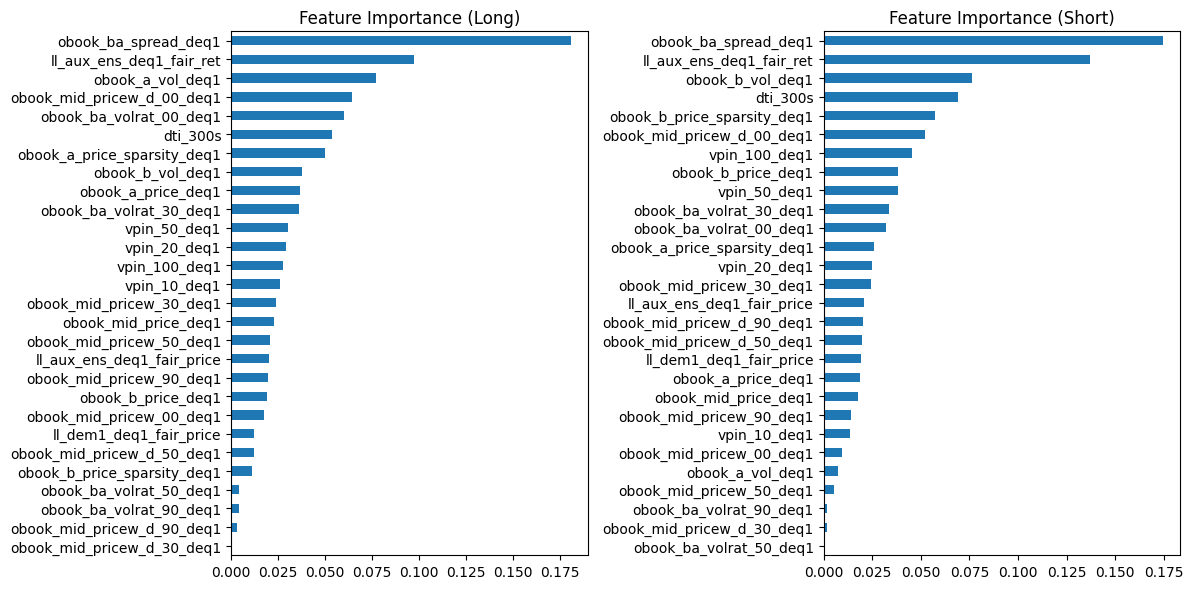

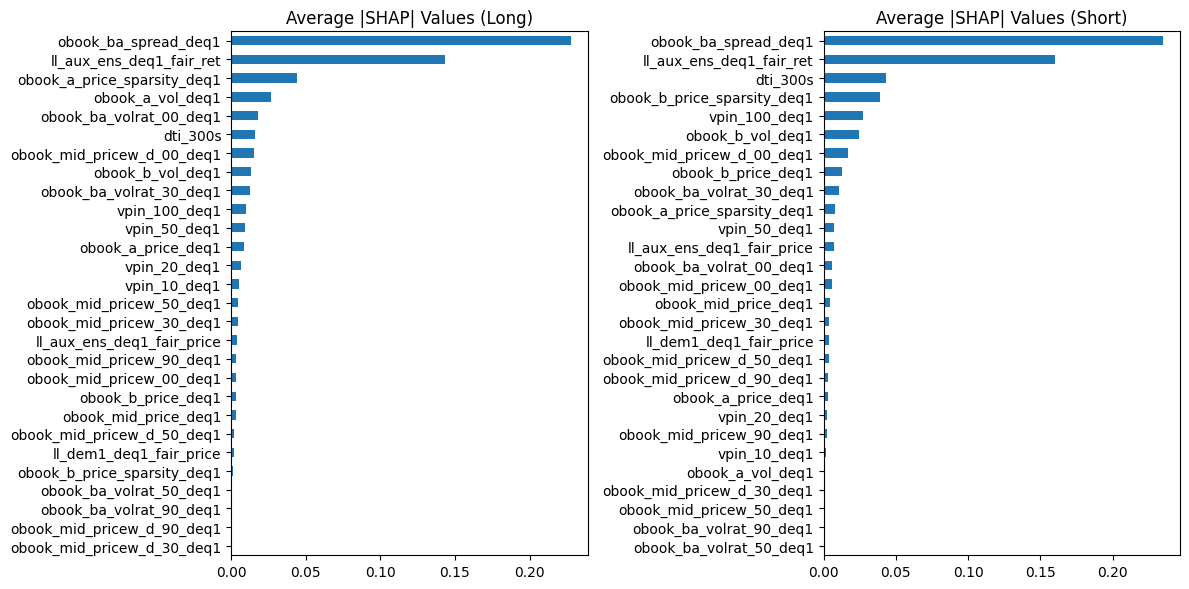


Top 5 Most Important Features (Long):
obook_ba_spread_deq1          0.180799
ll_aux_ens_deq1_fair_ret      0.097435
obook_a_vol_deq1              0.077347
obook_mid_pricew_d_00_deq1    0.064345
obook_ba_volrat_00_deq1       0.060010
dtype: float32

Top 5 Most Important Features (Short):
obook_ba_spread_deq1           0.174501
ll_aux_ens_deq1_fair_ret       0.137115
obook_b_vol_deq1               0.076544
dti_300s                       0.068928
obook_b_price_sparsity_deq1    0.057328
dtype: float32


In [40]:
from sklearn.preprocessing import StandardScaler
import shap
import numpy as np
import calendar
import xgboost as xgb
from xgboost import XGBClassifier

# Initialize for both long and short models
df_long['date'] = df_long['datetime'].dt.date
df_short['date'] = df_short['datetime'].dt.date

def train_and_evaluate_model(df, feature_cols, target_col, window_days=14):
    unique_dates = sorted(df['date'].unique())
    all_predictions = []
    all_actual_values = []
    all_probabilities = []
    all_dates = []
    feature_importance_list = []
    shap_values_list = []
    
    # For each date after the initial window
    for i in range(window_days, len(unique_dates)):
        current_date = unique_dates[i]
        
        # Get training data from the rolling window
        train_dates = unique_dates[i-window_days:i]
        train_mask = df['date'].isin(train_dates)
        test_mask = (df['date'] == current_date)
        
        X_train = df.loc[train_mask, feature_cols]
        y_train = df.loc[train_mask, target_col]
        X_test = df.loc[test_mask, feature_cols]
        y_test = df.loc[test_mask, target_col]
        
        # Skip if no test data for this date
        if len(X_test) == 0:
            continue
            
        # Train XGBoost model
        model = XGBClassifier(
            max_depth=3,
            learning_rate=0.1,
            n_estimators=10,
            scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),  # Handle class imbalance
            random_state=42
        )
        model.fit(X_train, y_train)
        
        # Make predictions
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        y_pred = (y_pred_proba > 0.5).astype(int)
        
        # Store feature importance for this window
        feature_importance_list.append(
            pd.Series(model.feature_importances_, index=feature_cols)
        )
        
        # Calculate SHAP values for feature importance
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)
        if isinstance(shap_values, list):  # For binary classification
            shap_values = shap_values[1]  # Take positive class
        shap_values_list.append(pd.DataFrame(shap_values, columns=feature_cols))
        
        # Store results
        all_predictions.extend(y_pred)
        all_actual_values.extend(y_test)
        all_probabilities.extend(y_pred_proba)
        all_dates.extend([current_date] * len(y_pred))
    
    # Calculate average feature importance across all windows
    avg_feature_importance = pd.concat(feature_importance_list, axis=1).mean(axis=1)
    avg_shap_values = pd.concat(shap_values_list).abs().mean()
    
    return pd.DataFrame({
        'date': all_dates,
        'actual': all_actual_values,
        'predicted': all_predictions,
        'probability': all_probabilities
    }), avg_feature_importance, avg_shap_values

# Train and evaluate long model
print("Training long model...")
results_long, importance_long, shap_long = train_and_evaluate_model(
    df_long, feature_cols, 'label_bid'
)
print(f"Overall accuracy (long): {accuracy_score(results_long['actual'], results_long['predicted']):.4f}")

# Train and evaluate short model
print("\nTraining short model...")
results_short, importance_short, shap_short = train_and_evaluate_model(
    df_short, feature_cols, 'label_ask'
)
print(f"Overall accuracy (short): {accuracy_score(results_short['actual'], results_short['predicted']):.4f}")

# Plot feature importance
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
importance_long.sort_values().plot(kind='barh')
plt.title('Feature Importance (Long)')
plt.tight_layout()

plt.subplot(1, 2, 2)
importance_short.sort_values().plot(kind='barh')
plt.title('Feature Importance (Short)')
plt.tight_layout()
plt.show()

# Plot SHAP values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
shap_long.sort_values().plot(kind='barh')
plt.title('Average |SHAP| Values (Long)')
plt.tight_layout()

plt.subplot(1, 2, 2)
shap_short.sort_values().plot(kind='barh')
plt.title('Average |SHAP| Values (Short)')
plt.tight_layout()
plt.show()

# Print top 5 most important features for each model
print("\nTop 5 Most Important Features (Long):")
print(importance_long.sort_values(ascending=False).head())
print("\nTop 5 Most Important Features (Short):")
print(importance_short.sort_values(ascending=False).head())